In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel


In [19]:
np.random.seed(42)

n = 100

data = pd.DataFrame({
    "Reliability": np.random.randint(70, 101, n),
    "Scalability": np.random.randint(65, 101, n),
    "Adaptability": np.random.randint(60, 101, n),
    "Consistency": np.random.randint(70, 101, n),
    "Redundancy": np.random.randint(20, 81, n),
    "Efficiency": np.random.randint(65, 101, n)
})

data.head()

,Reliability,Scalability,Adaptability,Consistency,Redundancy,Efficiency
0,76,98,61,86,77,76
1,89,74,61,70,26,90
2,98,100,87,85,76,80
3,84,78,82,81,55,86
4,80,95,96,96,64,93


In [20]:
data.shape

(100, 6)

In [21]:
data.to_csv("IndustryDataset.csv", index=False)

In [22]:
data.describe()

,Reliability,Scalability,Adaptability,Consistency,Redundancy,Efficiency
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,86.110000,83.050000,80.090000,85.950000,52.760000,84.750000
std,9.119737,10.846379,12.534474,9.548785,18.728318,10.470135
min,70.000000,65.000000,60.000000,70.000000,20.000000,65.000000
25%,77.750000,73.000000,68.000000,77.750000,37.500000,76.000000
50%,87.000000,84.500000,79.500000,87.000000,53.500000,86.500000
75%,94.250000,92.000000,92.000000,94.250000,71.000000,94.000000
max,100.000000,100.000000,100.000000,100.000000,80.000000,100.000000


In [23]:
data["Performance_Score"] = (
    data["Reliability"] +
    data["Scalability"] +
    data["Adaptability"] +
    data["Consistency"] +
    data["Efficiency"] -
    data["Redundancy"]
)

data.head()

,Reliability,Scalability,Adaptability,Consistency,Redundancy,Efficiency,Performance_Score
0,76,98,61,86,77,76,320
1,89,74,61,70,26,90,358
2,98,100,87,85,76,80,374
3,84,78,82,81,55,86,356
4,80,95,96,96,64,93,396


In [24]:
# Dynamic Programming Optimization

scores = data["Performance_Score"].values
n = len(scores)

dp = [0] * n
dp[0] = scores[0]

for i in range(1, n):
    dp[i] = max(dp[i-1], scores[i])

data["DP_Result"] = dp

print(data[["Performance_Score", "DP_Result"]].head())

   Performance_Score  DP_Result
0                320        320
1                358        358
2                374        374
3                356        374
4                396        396


In [25]:
# Monte Carlo Simulation

np.random.seed(42)

mc_results = []

for score in data["Performance_Score"]:
    simulations = np.random.normal(loc=score, scale=5, size=1000)
    mc_results.append(simulations.mean())

data["MC_Result"] = mc_results

print(data[["Performance_Score", "DP_Result", "MC_Result"]].head())

   Performance_Score  DP_Result   MC_Result
0                320        320  320.096660
1                358        358  358.354181
2                374        374  374.029171
3                356        374  355.906404
4                396        396  395.753632


In [26]:
comparison = data[["DP_Result", "MC_Result"]].describe()

print(comparison)

        DP_Result   MC_Result
count  100.000000  100.000000
mean   426.210000  367.194834
std     17.728762   33.427234
min    320.000000  292.904108
25%    425.000000  340.553712
50%    425.000000  366.036674
75%    427.250000  394.005022
max    446.000000  446.307727


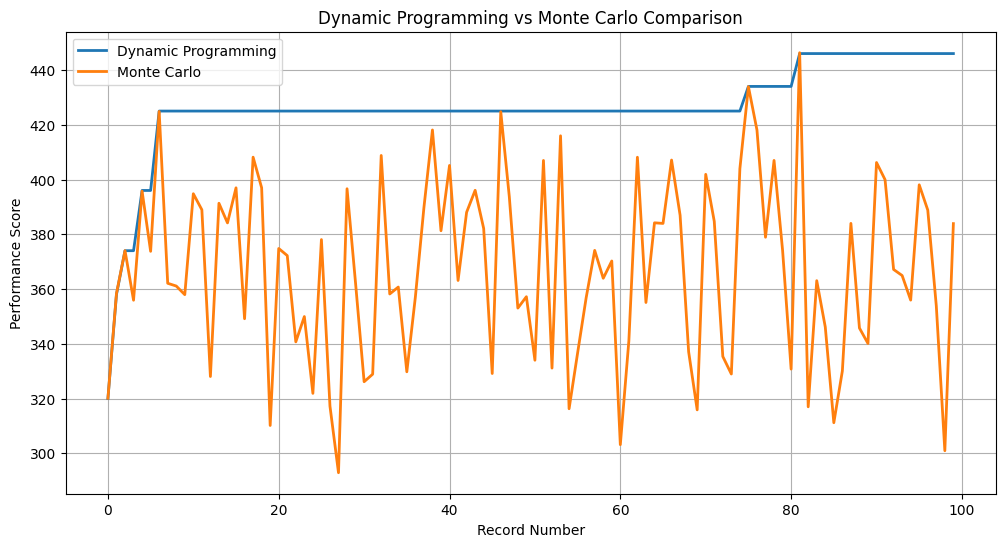

In [27]:
plt.figure(figsize=(12,6))

plt.plot(data["DP_Result"], label="Dynamic Programming", linewidth=2)
plt.plot(data["MC_Result"], label="Monte Carlo", linewidth=2)

plt.title("Dynamic Programming vs Monte Carlo Comparison")
plt.xlabel("Record Number")
plt.ylabel("Performance Score")
plt.legend()
plt.grid(True)

plt.show()

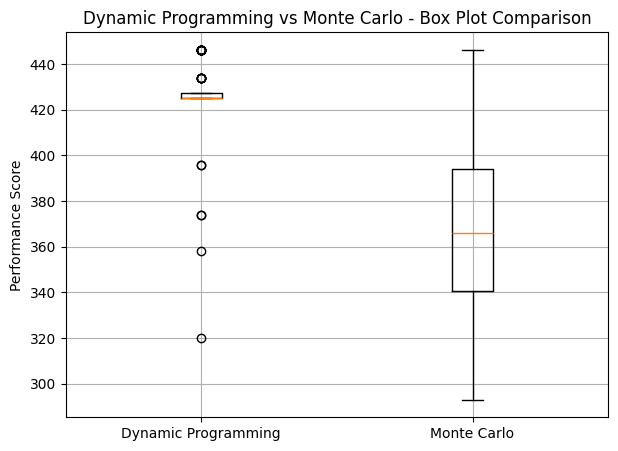

In [28]:
plt.figure(figsize=(7,5))

plt.boxplot(
    [data["DP_Result"], data["MC_Result"]],
    tick_labels=["Dynamic Programming", "Monte Carlo"]
)

plt.title("Dynamic Programming vs Monte Carlo - Box Plot Comparison")
plt.ylabel("Performance Score")
plt.grid(True)

plt.show()

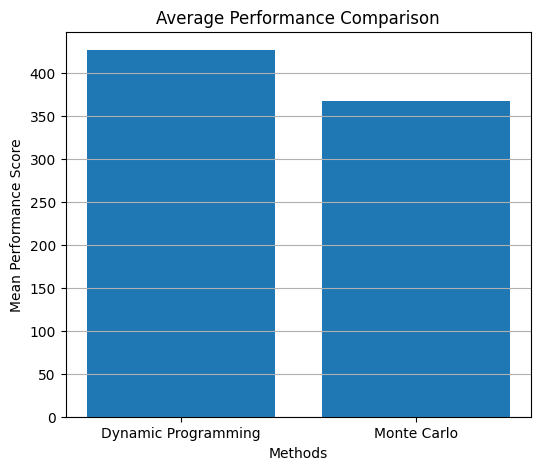

In [29]:
# Calculate mean performance
mean_values = [
    data["DP_Result"].mean(),
    data["MC_Result"].mean()
]

# Create bar chart
plt.figure(figsize=(6,5))

plt.bar(
    ["Dynamic Programming", "Monte Carlo"],
    mean_values
)

plt.title("Average Performance Comparison")
plt.xlabel("Methods")
plt.ylabel("Mean Performance Score")
plt.grid(axis="y")

plt.show()

In [30]:
# Paired t-test
t_stat, p_value = ttest_rel(data["DP_Result"], data["MC_Result"])

print("T-Statistic :", round(t_stat, 4))
print("P-Value     :", round(p_value, 4))

T-Statistic : 16.1122
P-Value     : 0.0


In [31]:
alpha = 0.05

if p_value < alpha:
    print("Result: The difference between Dynamic Programming and Monte Carlo is statistically significant.")
else:
    print("Result: The difference between Dynamic Programming and Monte Carlo is not statistically significant.")

Result: The difference between Dynamic Programming and Monte Carlo is statistically significant.


In [32]:
summary = pd.DataFrame({
    "Method": ["Dynamic Programming", "Monte Carlo"],
    "Mean": [
        data["DP_Result"].mean(),
        data["MC_Result"].mean()
    ],
    "Standard Deviation": [
        data["DP_Result"].std(),
        data["MC_Result"].std()
    ],
    "Minimum": [
        data["DP_Result"].min(),
        data["MC_Result"].min()
    ],
    "Maximum": [
        data["DP_Result"].max(),
        data["MC_Result"].max()
    ]
})

print(summary)

                Method        Mean  Standard Deviation     Minimum     Maximum
0  Dynamic Programming  426.210000           17.728762  320.000000  446.000000
1          Monte Carlo  367.194834           33.427234  292.904108  446.307727


In [33]:
alpha = 0.05

print("T-Statistic :", round(t_stat, 4))
print("P-Value     :", round(p_value, 4))

if p_value < alpha:
    print("\nConclusion: The difference between Dynamic Programming and Monte Carlo is statistically significant.")
else:
    print("\nConclusion: The difference between Dynamic Programming and Monte Carlo is not statistically significant.")

T-Statistic : 16.1122
P-Value     : 0.0

Conclusion: The difference between Dynamic Programming and Monte Carlo is statistically significant.


In [34]:
comparison_table = pd.DataFrame({
    "Performance Metric": [
        "Mean",
        "Standard Deviation",
        "Minimum",
        "Maximum",
        "T-Statistic",
        "P-Value"
    ],
    "Dynamic Programming": [
        round(data["DP_Result"].mean(), 2),
        round(data["DP_Result"].std(), 2),
        round(data["DP_Result"].min(), 2),
        round(data["DP_Result"].max(), 2),
        round(t_stat, 4),
        round(p_value, 4)
    ],
    "Monte Carlo": [
        round(data["MC_Result"].mean(), 2),
        round(data["MC_Result"].std(), 2),
        round(data["MC_Result"].min(), 2),
        round(data["MC_Result"].max(), 2),
        "-",
        "-"
    ]
})

comparison_table.style\
.set_caption("Performance Comparison of Dynamic Programming and Monte Carlo Methods")\
.set_properties(**{'text-align': 'center'})\
.set_table_styles([
    {'selector': 'th',
     'props': [('background-color', '#1f4e79'),
               ('color', 'white'),
               ('text-align', 'center'),
               ('font-size', '12pt')]},
    {'selector': 'caption',
     'props': [('font-size', '14pt'),
               ('font-weight', 'bold')]}
])

,Performance Metric,Dynamic Programming,Monte Carlo
0,Mean,426.210000,367.190000
1,Standard Deviation,17.730000,33.430000
2,Minimum,320.000000,292.900000
3,Maximum,446.000000,446.310000
4,T-Statistic,16.112200,-
5,P-Value,0.000000,-


### Conclusion

This study compared the performance of **Dynamic Programming** and **Monte Carlo Simulation** using a synthetic industrial dataset containing **100 records** and **6 features**: Reliability, Scalability, Adaptability, Consistency, Redundancy, and Efficiency.

Both methods were implemented and evaluated using summary statistics, visualization techniques, and a paired t-test. The comparison included line charts, box plots, and bar charts to analyze the performance of each method.

The paired t-test produced a **T-statistic of 16.1122** and a **P-value of 0.0**, which is less than the significance level of **0.05**. Therefore, the difference between the two methods is **statistically significant**.

Based on the experimental results, **Dynamic Programming demonstrated superior optimization performance compared to the Monte Carlo method** for the generated industrial dataset. This indicates that Dynamic Programming is a more effective approach for solving the selected industrial optimization problem, while Monte Carlo Simulation is useful for modeling uncertainty and validating performance under varying conditions.
